In [1]:
import ipyparallel as ipp

# Create and start a cluster with 2 MPI engines
cluster = ipp.Cluster(engines="mpi", n=2)
rc = cluster.start_and_connect_sync()

# Activate the client to use all engines
rc.activate()
print(f"Connected to {len(rc.ids)} engines.")

Starting 2 engines with <class 'ipyparallel.cluster.launcher.MPIEngineSetLauncher'>
100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2/2 [00:05<00:00,  2.92s/engine]
Connected to 2 engines.


In [2]:
%%px
import mpi4py.MPI as MPI
import os

from openpmd_viewer import OpenPMDTimeSeries
bp5_dir=f'/Users/dec2023/software/ECP-AMReX/TestApplications/WarpX/test-master-h5/diags/diag_bp5_f/'
ts = OpenPMDTimeSeries(bp5_dir)

comm = MPI.COMM_WORLD
rank = comm.Get_rank()
size = comm.Get_size()
host = os.uname().nodename

print(f"Rank {rank}/{size} running on host: {host}, PID: {os.getpid()}")
#Ex, info_Ex = ts.get_field( iteration=80, field='E', coord='x' )
Ex, info_Ex = ts.get_field( iteration=80, field='E', coord='x', plot=False ) ## can not plot 3D

z, = ts.get_particle( var_list=['z'], iteration=80, plot=True)

[stdout:0] ..... use MPI reader (size=2)
Rank 0/2 running on host: JunminD023sMBP5.localdomain, PID: 35534
rank= 0 start= 0 end= 74970
rank= 0 data= 74970 offset_portion= 74970


[stdout:1] Rank 1/2 running on host: JunminD023sMBP5.localdomain, PID: 35535
rank= 1 start= 74970 end= 149940
rank= 1 data= 74970 offset_portion= 74970


[stdout:0] ..... use MPI reader (size=2)
Rank 0/2 running on host: JunminD023sMBP5.localdomain, PID: 35694
rank= 0 start= 0 end= 74970
rank= 0 data= 74970 offset_portion= 74970
rank= 0 start= 0 end= 74970


[stdout:1] Rank 1/2 running on host: JunminD023sMBP5.localdomain, PID: 35695
rank= 1 start= 74970 end= 149940
rank= 1 data= 74970 offset_portion= 74970
rank= 1 start= 74970 end= 149940


[output:0]

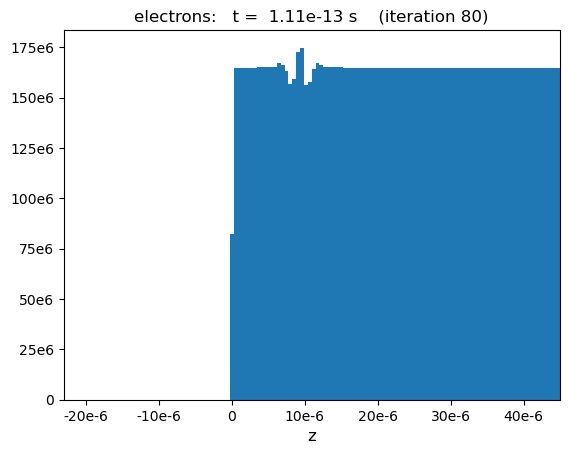

In [2]:
%%px
import mpi4py.MPI as MPI
import os

from openpmd_viewer import OpenPMDTimeSeries
bp5_dir=f'/Users/dec2023/software/ECP-AMReX/TestApplications/WarpX/test-master-h5/diags/diag_bp5_f/'
ts = OpenPMDTimeSeries(bp5_dir)

comm = MPI.COMM_WORLD
rank = comm.Get_rank()
size = comm.Get_size()
host = os.uname().nodename

print(f"Rank {rank}/{size} running on host: {host}, PID: {os.getpid()}")
#Ex, info_Ex = ts.get_field( iteration=80, field='E', coord='x' )
Ex, info_Ex = ts.get_field( iteration=80, field='E', coord='x', plot=False ) ## can not plot 3D

z, = ts.get_particle( var_list=['z'], iteration=80, plot=True)